## Predicting House Prices with Linear Models

Notebook consists of:

1. Preprocessing the Data
2. EDA of the Data
3. Feature Engineering
4. Linear Model Training
5. XGBoost Benchmarking
6. Model Interpretation

In [16]:
# -------- initialise ----------
DATA_PATH = "data/house_dataset.csv"
RANDOM_SEED = 42

In [ ]:
# -------- our internal helper imports --------------

from utils.feature_engineering_helpers import run_feature_engineering
from utils.data_preprocessing_helpers import build_preprocessor
from utils.evaluation_helpers import mape, mape_scorer, cv_mape

# -------- external imports --------------
import pandas as pd
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import xgboost as xgb

### Step 1: Preprocessing

In [25]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(1)

Shape: (9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA


In [19]:
# make sure date column is in DateTime format
df['date'] = pd.to_datetime(df['date'])

# check and print only if there is any missing data
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("Missing data found:")
    print(missing_data[missing_data > 0])
else:
    print("No missing data found.")

No missing data found.


In [ ]:
## TODO - more ways to preprocess
#  check for outliers and remove them 
# do train/test split here as well ( do we want to have 2 options, random & time based? which we can toggle later on for model comparison)

### Step 2. EDA

Numeric columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


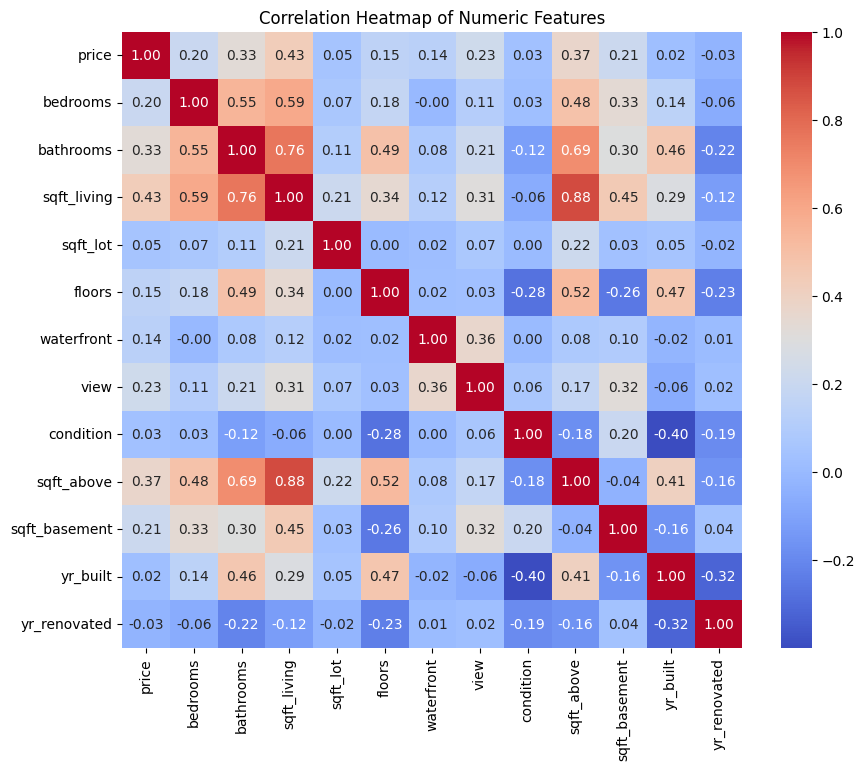

In [20]:
# get list of numeric columns in data
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# plot correlation heatmap of numeric features to target 'price'
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
## TODO: ideas for more EDA, 
## get list of categorical columns and check what their median price is
## similarly plot price against date column - check for monthly/yearly/seasonality trends

### Step 3: Feature Engineering

In [ ]:
## TODO: based on EDA we can create a masterlist of engineered features
"""
current RAW columns avalaible in data: 
   date, price, bedrooms, bathrooms, sqft_living, sqft_lot,
    floors, waterfront, view, condition, sqft_above,
    sqft_basement, yr_built, yr_renovated, street, city,
    statezip, country
    
"""

"""
ADDITIONAL features we can create:
 TODO make list here
 
 ( some ideas are time features, example: effective_age of house = yr_built-yr_renovated,
 space features like sqft/bedroom, interaction features like: size x condition )
"""


'\nADDITIONAL features we can create:\n TODO make list here\n\n ( some ideas are time features, example: effective_age of house = yr_built-yr_renovated,\n space features like sqft/bedroom, interaction features like: size x condition )\n'

In [ ]:
# TODO: create the final feature set we want to train models on
BINARY_COLS = []
ORDINAL_COLS = []
CONTNOUS_COLS = []

### Step 4: Linear Model Training

In [ ]:
# ── Model factory ─────────────────────────────────────────────
# Add / tweak models here, these are the basic ones - if we want to use different features/different train test splits we can add them here

preprocessor = build_preprocessor(X_train_fe, BINARY_COLS, ORDINAL_COLS, CONTNOUS_COLS) 

ALPHAS = np.logspace(-3, 4, 50)

MODELS = {
    "OLS"       : Pipeline([("pre", preprocessor), ("model", LinearRegression())]),
    "Ridge"     : Pipeline([("pre", preprocessor), ("model", RidgeCV(alphas=ALPHAS, cv=CV_FOLDS))]),
    "Lasso"     : Pipeline([("pre", preprocessor), ("model", LassoCV(alphas=ALPHAS, cv=CV_FOLDS, max_iter=5000))]),
    "ElasticNet": Pipeline([("pre", preprocessor), ("model", ElasticNetCV(cv=CV_FOLDS, max_iter=5000))]),
}

print("Models defined:", list(MODELS.keys()))

In [ ]:
# TODO: do cross-validated MAPE here for each model and print results

In [ ]:
# TODO: then pick WINNER model from above results and train on ALL training data

### Step 5: XGBoost Benchmark

In [ ]:
# TODO: train xgboost model on all training data & get preds on test, compare with WINNER preds above

### Step 6: Model Intepretation

In [ ]:
# TODO: print feature_names & coefficients
# TODO: bar chart of top features
# TODO: paragraph to explain